In [51]:
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns;sns.set_theme()
sns.set_color_codes()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp2d
import matplotlib.colors as colors

%matplotlib inline
sns.set_style('white')
sns.set_style("ticks")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# === Load precomputed analytical grids ===
# RUE
rue_file = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/rue_ana_heatmap1_aw_1_10_length_10.txt'
RUE = pd.read_csv(rue_file, header=None).values

# Flux J
flux_file = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/te_ana_heatmap1_aw_1_10_length_10.txt'
J = pd.read_csv(flux_file, header=None).values

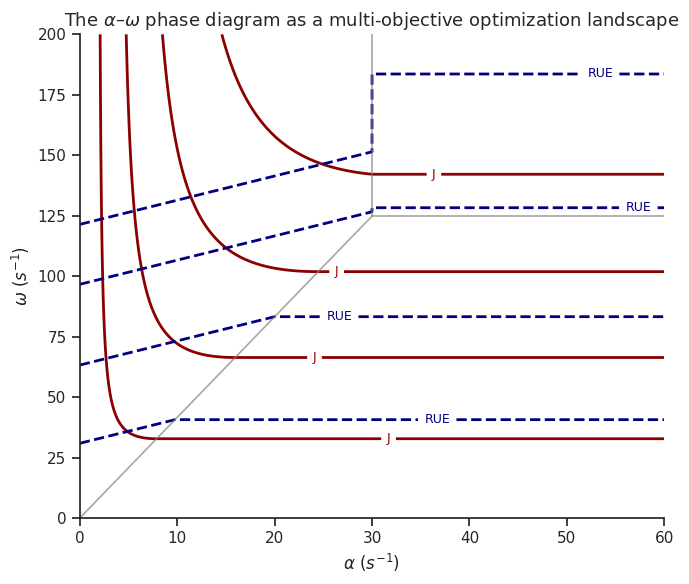

In [54]:
alpha = np.linspace(0.001, 60, RUE.shape[1])
omega = np.linspace(0.001, 200, RUE.shape[0])

alpha= np.linspace(0.0,60,10000);
omega = np.linspace(0.0,200,1000);

A, W = np.meshgrid(alpha, omega)
rho = np.divide(J, RUE, out=np.zeros_like(J), where=RUE>0)
rho = np.divide(J, RUE, out=np.zeros_like(J), where=RUE>0)
def quantile_levels(Z, qs=[0.2,0.4,0.6,0.8]):
    vals = Z[np.isfinite(Z)]
    return np.quantile(vals, qs)



levels_J   = quantile_levels(J)
levels_RUE = quantile_levels(RUE)
levels_rho = quantile_levels(rho)
fig, ax = plt.subplots(figsize=(7,6))
# for q, val in zip(qs, levels_J):
#     print(f"J at {int(q*100)}% quantile = {val:.4f}")



# === Iso-Flux (J): solid, warm ===
csJ = ax.contour(A, W, J, levels=levels_J,
                 colors='darkred', linewidths=2.0)
ax.clabel(csJ, fmt='J', fontsize=9)

# === Iso-RUE: dashed, cool ===
csRUE = ax.contour(A, W, RUE, levels=levels_RUE,
                   colors='navy', linestyles='--', linewidths=2.0)
ax.clabel(csRUE, fmt='RUE', fontsize=9)





# # === Iso-Density: dotted, gray ===
# csRHO = ax.contour(A, W, rho, levels=levels_rho,
#                    colors='black', linestyles=':', linewidths=1.5)
# ax.clabel(csRHO, fmt=r'$\rho$', fontsize=9)
beta = 30
ell = 10
c = 1 + np.sqrt(ell)

x = np.linspace(0.001, beta, 200)
y = c * x

# LD–MC
ax.plot(x, y, color='gray', lw=1.2, alpha=0.7)

# MC–HD
ax.hlines(beta*c, beta, 60, color='gray', lw=1.2, alpha=0.7)
ax.vlines(beta, beta*c, 200, color='gray', lw=1.2, alpha=0.7)
# ax.fill_between(x, 0.001, y, color='lightgray', alpha=0.25, zorder=0)
# ax.set_xscale('log')
# ax.set_yscale('log')

ax.set_xlabel(r'$\alpha\ (s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\omega\ (s^{-1})$', fontsize=12)

ax.set_title(
    r'The $\alpha$–$\omega$ phase diagram as a multi-objective optimization landscape',
    fontsize=13
)

sns.despine()
plt.tight_layout()
plt.show()

Iso-flux (J) contour values:
  20% quantile : J = 1.8952
  40% quantile : J = 3.8334
  60% quantile : J = 5.8819
  80% quantile : J = 8.1637

Iso-RUE contour values:
  20% quantile : RUE = 30.9350
  40% quantile : RUE = 63.2742
  60% quantile : RUE = 96.6502
  80% quantile : RUE = 121.4303


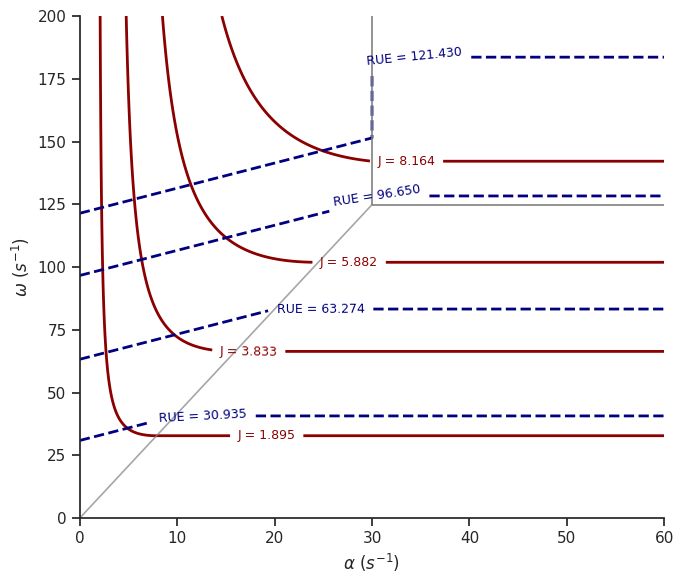

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

# --------------------------------------------------
# Define α–ω grid (must match J, RUE shape)
# --------------------------------------------------
alpha = np.linspace(0.0, 60, 10000)
omega = np.linspace(0.0, 200, 1000)
A, W = np.meshgrid(alpha, omega)

# --------------------------------------------------
# Derived quantity
# --------------------------------------------------
rho = np.divide(J, RUE, out=np.zeros_like(J), where=RUE > 0)

# --------------------------------------------------
# Quantile function
# --------------------------------------------------
def quantile_levels(Z, qs=[0.2, 0.4, 0.6, 0.8]):
    vals = Z[np.isfinite(Z)]
    return np.quantile(vals, qs)

qs = [0.2, 0.4, 0.6, 0.8]

levels_J   = quantile_levels(J, qs)
levels_RUE = quantile_levels(RUE, qs)
levels_rho = quantile_levels(rho, qs)

# --------------------------------------------------
# Print numerical values of J isotherms
# --------------------------------------------------
print("Iso-flux (J) contour values:")
for q, val in zip(qs, levels_J):
    print(f"  {int(q*100)}% quantile : J = {val:.4f}")

print("\nIso-RUE contour values:")
for q, val in zip(qs, levels_RUE):
    print(f"  {int(q*100)}% quantile : RUE = {val:.4f}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

# Iso-Flux
csJ = ax.contour(A, W, J, levels=levels_J,
                 colors='darkred', linewidths=2.0)
# ax.clabel(csJ, fmt='J', fontsize=9)
ax.clabel(csJ,
          fmt=lambda x: f"J = {x:.3f}",
          fontsize=9)

# Iso-RUE
csRUE = ax.contour(A, W, RUE, levels=levels_RUE,
                   colors='navy', linestyles='--', linewidths=2.0)
# ax.clabel(csRUE, fmt='RUE', fontsize=9)
ax.clabel(csRUE,
          fmt=lambda x: f"RUE = {x:.3f}",
          fontsize=9)

# --------------------------------------------------
# Phase boundaries
# --------------------------------------------------
beta = 30
ell = 10
c = 1 + np.sqrt(ell)

x = np.linspace(0.001, beta, 200)
ax.plot(x, c * x, color='gray', lw=1.2, alpha=0.7)      # LD–MC
ax.hlines(beta * c, beta, 60, color='gray', lw=1.2)    # MC–HD
ax.vlines(beta, beta * c, 200, color='gray', lw=1.2)

# --------------------------------------------------
# Labels
# --------------------------------------------------
ax.set_xlabel(r'$\alpha\ (s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\omega\ (s^{-1})$', fontsize=12)

# ax.set_title(
#     r'The $\alpha$–$\omega$ phase diagram',
#     fontsize=13
# )

sns.despine()
plt.tight_layout()
plt.show()


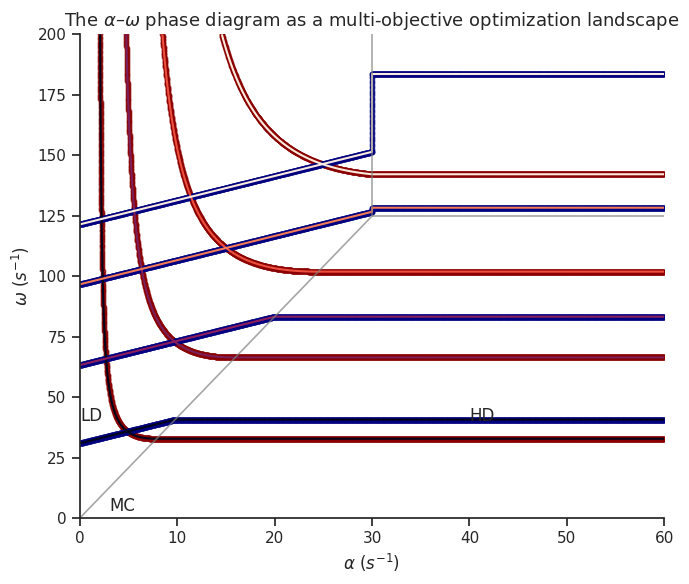

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

# =====================================================
# α–ω grid
# =====================================================
alpha = np.linspace(0.0, 60, 10000)
omega = np.linspace(0.0, 200, 1000)
A, W = np.meshgrid(alpha, omega)

# -----------------------------------------------------
# J and RUE must already exist with shape (1000, 10000)
# -----------------------------------------------------
# J   : flux array
# RUE : ribosome utilization efficiency array

# =====================================================
# Helper: quantile levels
# =====================================================
def quantile_levels(Z, qs=[0.2, 0.4, 0.6, 0.8]):
    Z = Z[np.isfinite(Z)]
    return np.quantile(Z, qs)

levels_J   = quantile_levels(J)
levels_RUE = quantile_levels(RUE)

# =====================================================
# Figure
# =====================================================
fig, ax = plt.subplots(figsize=(7, 6))

# =====================================================
# Iso-Flux (J) → POINTS
# =====================================================
csJ = ax.contour(A, W, J, levels=levels_J)

for level_segs in csJ.allsegs:
    for seg in level_segs:
        ax.scatter(seg[::5, 0], seg[::5, 1],   # subsample
                   s=10,
                   color='darkred',
                   alpha=0.7)

# =====================================================
# Iso-RUE → POINTS
# =====================================================
csRUE = ax.contour(A, W, RUE, levels=levels_RUE)

for level_segs in csRUE.allsegs:
    for seg in level_segs:
        ax.scatter(seg[::5, 0], seg[::5, 1],
                   s=10,
                   color='navy',
                   alpha=0.7)

# =====================================================
# Phase boundaries
# =====================================================
beta = 30
ell = 10
c = 1 + np.sqrt(ell)

x = np.linspace(0.001, beta, 300)

# LD–MC boundary
ax.plot(x, c * x, color='gray', lw=1.2, alpha=0.7)

# MC–HD boundaries
ax.hlines(beta * c, beta, 60, color='gray', lw=1.2, alpha=0.7)
ax.vlines(beta, beta * c, 200, color='gray', lw=1.2, alpha=0.7)

# =====================================================
# Regime labels (optional but recommended)
# =====================================================
ax.text(0.02, 40, 'LD', fontsize=12)
ax.text(3, 3, 'MC', fontsize=12)
ax.text(40, 40, 'HD', fontsize=12)

# =====================================================
# Formatting
# =====================================================
ax.set_xlim(0, 60)
ax.set_ylim(0, 200)

ax.set_xlabel(r'$\alpha\ (s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\omega\ (s^{-1})$', fontsize=12)

ax.set_title(
    r'The $\alpha$–$\omega$ phase diagram as a multi-objective optimization landscape',
    fontsize=13
)

sns.despine()
plt.tight_layout()
plt.show()


In [49]:
J


array([[          nan, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 4.5840000e-03, 7.3280000e-03, ..., 1.1556000e-02,
        1.1556000e-02, 1.1556000e-02],
       [0.0000000e+00, 5.2080000e-03, 9.1680000e-03, ..., 2.3112000e-02,
        2.3112000e-02, 2.3112000e-02],
       ...,
       [0.0000000e+00, 5.9990000e-03, 1.1994000e-02, ..., 1.0834737e+01,
        1.0834737e+01, 1.0834737e+01],
       [0.0000000e+00, 5.9990000e-03, 1.1994000e-02, ..., 1.0842904e+01,
        1.0842904e+01, 1.0842904e+01],
       [0.0000000e+00, 5.9990000e-03, 1.1994000e-02, ..., 1.0851064e+01,
        1.0851064e+01, 1.0851064e+01]])

In [27]:
ell = 10          # ribosome footprint
beta = 30.0       # termination rate (s^-1)
c = 1 + np.sqrt(ell)
def flux_LD(alpha, omega):
    return (alpha * (1 - alpha/omega)) / (1 + (ell-1)*alpha/omega)

def rho_LD(alpha, omega):
    return (alpha/omega) / (1 + (ell-1)*alpha/omega)

def flux_HD(omega):
    return (beta * (1 - beta/omega)) / (1 + (ell-1)*beta/omega)

def rho_HD(omega):
    return 1 - beta/(omega*ell)

def flux_MC(omega):
    return omega / (1 + np.sqrt(ell))**2

def rho_MC():
    return 1 / (np.sqrt(ell)*(1 + np.sqrt(ell)))

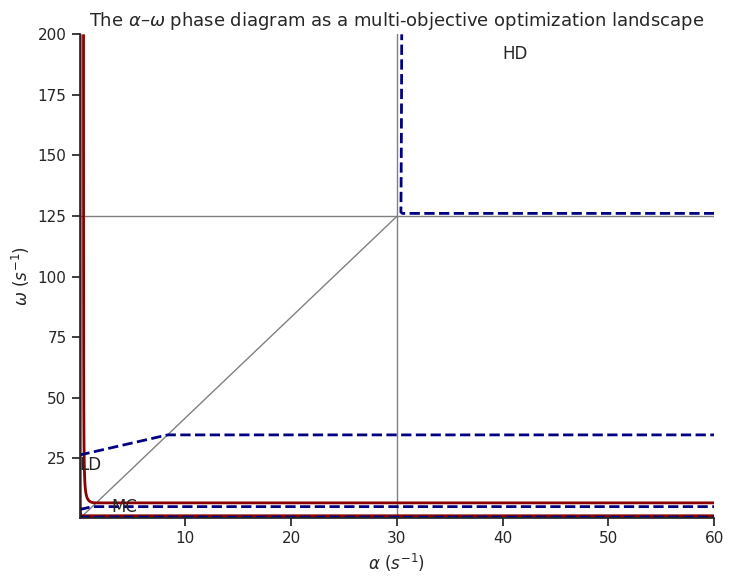

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

# Grid
alpha = np.logspace(-2, np.log10(60), 400)
omega = np.logspace(-1, np.log10(200), 400)
A, W = np.meshgrid(alpha, omega)

J = np.zeros_like(A)
rho = np.zeros_like(A)
RUE = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        a = A[i,j]
        w = W[i,j]

        # LD
        if (a < beta) and (w > a*c):
            J[i,j]   = flux_LD(a, w)
            rho[i,j] = rho_LD(a, w)

        # HD
        elif (a > beta) and (w > beta*c):
            J[i,j]   = flux_HD(w)
            rho[i,j] = rho_HD(w)

        # MC
        elif (w < a*c) and (w < beta*c):
            J[i,j]   = flux_MC(w)
            rho[i,j] = rho_MC()

        else:
            J[i,j] = np.nan
            rho[i,j] = np.nan

RUE = J / rho
def qlevels(Z):
    Z = Z[np.isfinite(Z)]
    return np.quantile(Z, [0.25, 0.5, 0.75])

J_lvls   = qlevels(J)
RUE_lvls = qlevels(RUE)
rho_lvls = qlevels(rho)
fig, ax = plt.subplots(figsize=(7.5,6))

# --- Background: regimes ---
# x = np.linspace(1e-2, beta, 300)
# ax.fill_between(x, 1e-1, c*x, color='lightgray', alpha=0.3, label='LD')

ax.axvline(beta, color='gray', lw=1)
ax.axhline(beta*c, color='gray', lw=1)
ax.plot(x, c*x, color='gray', lw=1)

ax.text(0.03, 20, "LD", fontsize=12)
ax.text(40, 190, "HD", fontsize=12)
ax.text(3, 3, "MC", fontsize=12)

# --- Iso-contours ---
ax.contour(A, W, J, levels=J_lvls,
           colors='darkred', linewidths=2, linestyles='-')
ax.contour(A, W, RUE, levels=RUE_lvls,
           colors='navy', linewidths=2, linestyles='--')
# ax.contour(A, W, rho, levels=rho_lvls,
#            colors='black', linewidths=1.5, linestyles=':')

# --- Axes ---
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(0.03,60)
ax.set_ylim(0.3,200)

ax.set_xlabel(r'$\alpha\ (s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\omega\ (s^{-1})$', fontsize=12)

ax.set_title(r'The $\alpha$–$\omega$ phase diagram as a multi-objective optimization landscape',
             fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-489805926.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_wild = pd.read_csv(url_wild, delim_whitespace=True)
/tmp/ipython-input-489805926.py:109: RuntimeWarning: invalid value encountered in divide
  rho_vals = J_vals / RUE_vals


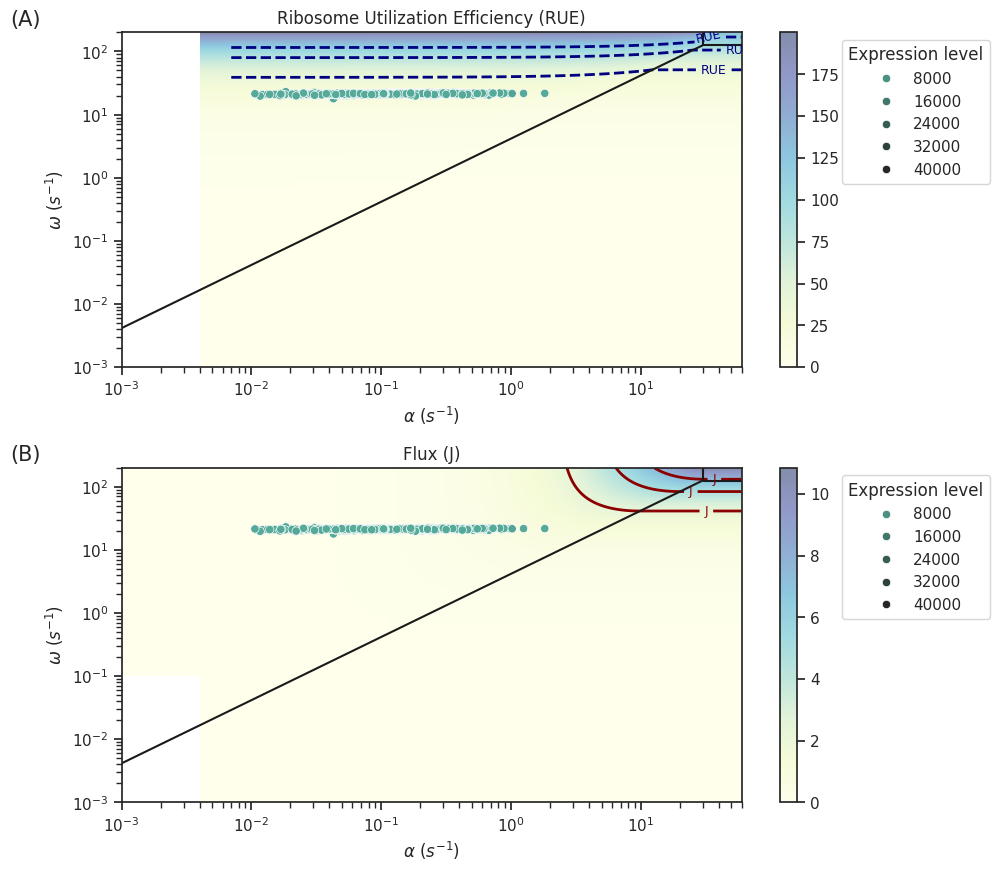

In [41]:
#################################### Fig 4 ###########################################
# Minimal modification: add isotherms on top of existing heatmaps
######################################################################################

from google.colab import drive
drive.mount('/content/drive')

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme()
sns.set_style("ticks")
%matplotlib inline

#################################### Load data #######################################

# RUE heatmap
url_rue = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/rue_ana_heatmap1_aw_1_10_length_10.txt'
df_rue = pd.read_csv(url_rue, sep=',', header=None)

# Flux heatmap
url_flux = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/te_ana_heatmap1_aw_1_10_length_10.txt'
df_flux = pd.read_csv(url_flux, sep=',', header=None)

# E. coli genes
url_wild = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/te_ad_rue_exp_ir_w_inayat_rate.txt'
df_wild = pd.read_csv(url_wild, delim_whitespace=True)
df_wild.columns = ['g_no','gene','gene_name2','te','ad','rue','exp_level','a','w']

#################################### Axes and grid ###################################

alpha_rates = np.linspace(0.001, 60, df_rue.shape[1])
omega_rates = np.linspace(0.001, 200, df_rue.shape[0])

beta = 30
ell = 10
c = 1 + np.sqrt(ell)
x = np.linspace(0.001, beta, 200)
y = c * x

#################################### Figure ##########################################

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharey=False)

for a, lab in zip(ax, ['(A)', '(B)']):
    a.annotate(lab, xy=(-0.18, 1.02), xycoords="axes fraction", fontsize=15)

######################################################################################
# (A) RUE panel
######################################################################################

ax[0].set_xscale("log")
ax[0].set_yscale("log")

im0 = ax[0].pcolormesh(alpha_rates, omega_rates, df_rue,
                       cmap='YlGnBu', alpha=0.5)
fig.colorbar(im0, ax=ax[0])

# ---- RUE isotherms (dashed blue) ----
RUE_vals = df_rue.values
levels_rue = np.quantile(RUE_vals[np.isfinite(RUE_vals)], [0.25, 0.5, 0.75])

cs_rue = ax[0].contour(alpha_rates, omega_rates, RUE_vals,
                       levels=levels_rue,
                       colors='navy',
                       linestyles='--',
                       linewidths=2)
ax[0].clabel(cs_rue, fmt='RUE', fontsize=9)

# ---- Phase boundaries ----
ax[0].plot(x, y, color="k", linewidth=1.5)
ax[0].hlines(beta*c, beta, 60, color="k", linewidth=1.5)
ax[0].vlines(beta, beta*c, 200, color="k", linewidth=1.5)

# ---- E. coli genes ----
sns.scatterplot(data=df_wild, x="a", y="w",
                hue="exp_level", palette="dark:#5A9_r", ax=ax[0])

ax[0].set_title('Ribosome Utilization Efficiency (RUE)')
ax[0].set_xlabel(r'$\alpha\ (s^{-1})$')
ax[0].set_ylabel(r'$\omega\ (s^{-1})$')
ax[0].legend(loc="upper left", bbox_to_anchor=(1.15, 1), title="Expression level")

######################################################################################
# (B) Flux panel
######################################################################################

ax[1].set_xscale("log")
ax[1].set_yscale("log")

im1 = ax[1].pcolormesh(alpha_rates, omega_rates, df_flux,
                       cmap='YlGnBu', alpha=0.5)
fig.colorbar(im1, ax=ax[1])

# ---- Flux isotherms (solid red) ----
J_vals = df_flux.values
levels_J = np.quantile(J_vals[np.isfinite(J_vals)], [0.25, 0.5, 0.75])

cs_J = ax[1].contour(alpha_rates, omega_rates, J_vals,
                     levels=levels_J,
                     colors='darkred',
                     linestyles='-',
                     linewidths=2)
ax[1].clabel(cs_J, fmt='J', fontsize=9)

# ---- Optional: density isotherms (dotted black) ----
rho_vals = J_vals / RUE_vals
levels_rho = np.quantile(rho_vals[np.isfinite(rho_vals)], [0.25, 0.5, 0.75])

# ax[1].contour(alpha_rates, omega_rates, rho_vals,
#               levels=levels_rho,
#               colors='black',
#               linestyles=':',
#               linewidths=1.5)

# ---- Phase boundaries ----
ax[1].plot(x, y, color="k", linewidth=1.5)
ax[1].hlines(beta*c, beta, 60, color="k", linewidth=1.5)
ax[1].vlines(beta, beta*c, 200, color="k", linewidth=1.5)

# ---- E. coli genes ----
sns.scatterplot(data=df_wild, x="a", y="w",
                hue="exp_level", palette="dark:#5A9_r", ax=ax[1])

ax[1].set_title('Flux (J)')
ax[1].set_xlabel(r'$\alpha\ (s^{-1})$')
ax[1].set_ylabel(r'$\omega\ (s^{-1})$')
ax[1].legend(loc="upper left", bbox_to_anchor=(1.15, 1), title="Expression level")

######################################################################################

fig.subplots_adjust(hspace=0.3)
plt.show()

# fig.savefig("FIG_4_with_isotherms.jpg",
#             transparent=True, bbox_inches='tight', pad_inches=0, dpi=1000)

# from google.colab import files
# files.download('/content/FIG_4_with_isotherms.jpg')


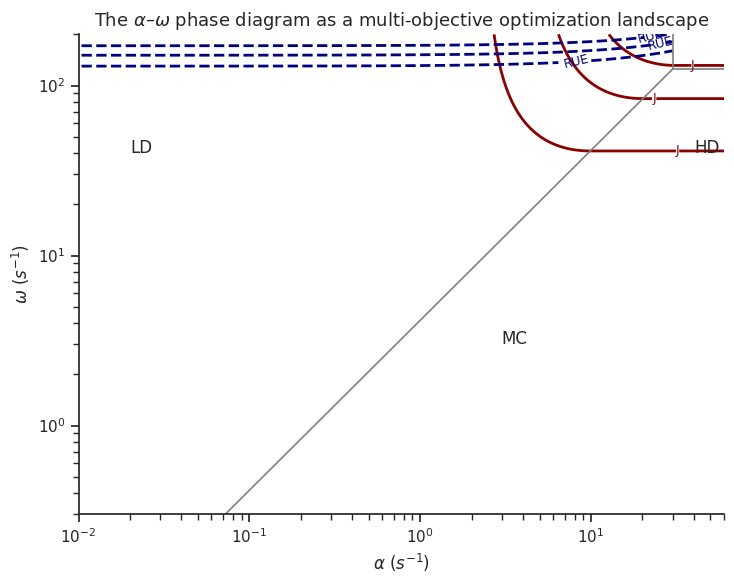

In [42]:
############################################
# α–ω phase diagram: multi-objective landscape
# RUE (LD-only isotherms) + Flux (global)
############################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

############################################
# Load analytical heatmaps (same as before)
############################################

rue_file = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/rue_ana_heatmap1_aw_final_length_10.txt'
flux_file = '/content/drive/MyDrive/Colab Notebooks/Heatmap_realistic_rates/Figure_4_ecoli/te_ana_heatmap1_aw_final_length_10.txt'

RUE = pd.read_csv(rue_file, header=None).values
J   = pd.read_csv(flux_file, header=None).values

############################################
# α–ω grid (must match heatmap resolution)
############################################

alpha = np.linspace(0.001, 60, RUE.shape[1])
omega = np.linspace(0.001, 200, RUE.shape[0])
A, W = np.meshgrid(alpha, omega)

############################################
# Parameters and phase boundaries
############################################

beta = 30.0
ell  = 10
c    = 1 + np.sqrt(ell)

############################################
# Define LD mask (CRITICAL FIX)
############################################
# LD: alpha < beta AND omega > c * alpha

LD_mask = (A < beta) & (W > c * A)

############################################
# Mask RUE outside LD
############################################

RUE_LD = np.where(LD_mask, RUE, np.nan)

############################################
# Density (only if needed)
############################################

rho = np.divide(J, RUE, out=np.nan*np.ones_like(J), where=RUE>0)

############################################
# Choose contour levels
############################################

# Flux: global quantiles
J_levels = np.quantile(J[np.isfinite(J)], [0.25, 0.5, 0.75])

# RUE: HIGH quantiles, LD ONLY
RUE_levels = np.quantile(
    RUE_LD[np.isfinite(RUE_LD)],
    [0.6, 0.75, 0.9]
)

############################################
# Plot
############################################

fig, ax = plt.subplots(figsize=(7.5, 6))

# ---- Iso-Flux (solid red) ----
csJ = ax.contour(A, W, J,
                 levels=J_levels,
                 colors='darkred',
                 linewidths=2)
ax.clabel(csJ, fmt='J', fontsize=9)

# ---- Iso-RUE (dashed blue, LD ONLY) ----
csRUE = ax.contour(A, W, RUE_LD,
                   levels=RUE_levels,
                   colors='navy',
                   linestyles='--',
                   linewidths=2)
ax.clabel(csRUE, fmt='RUE', fontsize=9)

############################################
# Phase boundaries
############################################

x = np.linspace(0.001, beta, 300)
ax.plot(x, c*x, color='gray', lw=1.2)                 # LD–MC
ax.vlines(beta, beta*c, 200, color='gray', lw=1.2)   # HD boundary
ax.hlines(beta*c, beta, 60, color='gray', lw=1.2)

############################################
# Regime labels
############################################

ax.text(0.02, 40, 'LD', fontsize=12)
ax.text(3, 3, 'MC', fontsize=12)
ax.text(40, 40, 'HD', fontsize=12)

############################################
# Axes and formatting
############################################

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(0.01, 60)
ax.set_ylim(0.3, 200)

ax.set_xlabel(r'$\alpha\ (s^{-1})$', fontsize=12)
ax.set_ylabel(r'$\omega\ (s^{-1})$', fontsize=12)

ax.set_title(
    r'The $\alpha$–$\omega$ phase diagram as a multi-objective optimization landscape',
    fontsize=13
)

sns.despine()
plt.tight_layout()
plt.show()
